In [1]:
# Create a cell and run this first to generate the data
!cd Person-in-WiFi-3D-repo && python tools/test.py configs/wifi/petr_wifi.py /home/axnguyen/Data/WiFi-CSI/result_v1/latest.pth --eval keypoints


/data/axnguyen/Env/Anaconda/envs/WiFi-CSI/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/data/axnguyen/Env/Anaconda/envs/WiFi-CSI/lib/python3.10/site-packages/mmdet/utils/setup_env.py:38: UserWarning: Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed.
  warnings.warn(
/data/axnguyen/Env/Anaconda/envs/WiFi-CSI/lib/python3.10/site-packages/mmdet/utils/setup_env.py:48: UserWarning: Setting MKL_NUM_THREADS environment variable for each process to be 1 in default, to avoid you

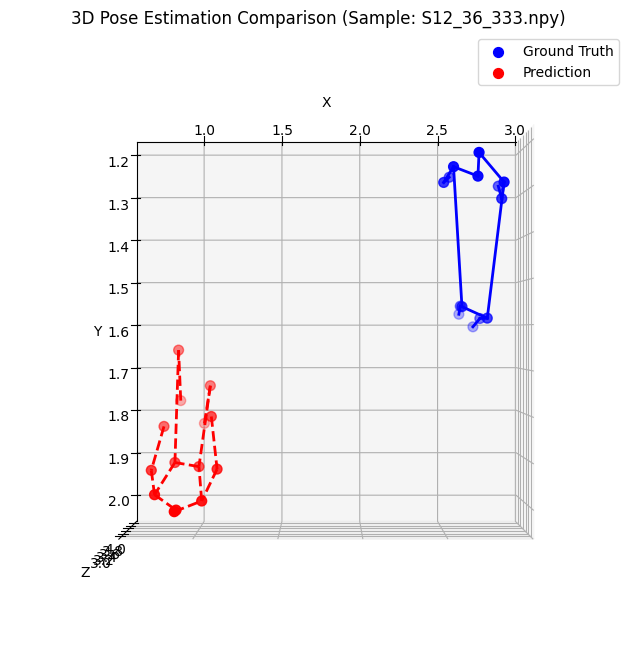

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

vis_dir = '/home/axnguyen/Data/WiFi-CSI/result/visualize'

# Get the first test sample file name
sample_files = os.listdir(os.path.join(vis_dir, 'pose_gt'))
if len(sample_files) == 0:
    print("No evaluation data found! Did you run test.py first?")
else:
    sample_name = sample_files[0] 
    
    # Load Ground Truth and Prediction
    gt_pose = np.load(os.path.join(vis_dir, 'pose_gt', sample_name))
    pred_pose = np.load(os.path.join(vis_dir, 'pose_pred', sample_name))

    # The array shape is (num_people, 14_joints, 3_coords)
    # Let's plot the first person
    gt_person = gt_pose[0]
    pred_person = pred_pose[0]

    # Standard 14-joint connections for plotting the skeleton lines
    skeleton_lines = [[0,1], [1,2], [2,5], [3,0], [4,2], [5,7],
                      [6,3], [7,3], [8,4], [9,5], [10,6], [11,7],
                      [12,9], [13,11]]

    # Setup the 3D Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot Ground Truth (Blue)
    ax.scatter(gt_person[:, 0], gt_person[:, 1], gt_person[:, 2], c='blue', s=50, label='Ground Truth')
    for line in skeleton_lines:
        ax.plot([gt_person[line[0], 0], gt_person[line[1], 0]],
                [gt_person[line[0], 1], gt_person[line[1], 1]],
                [gt_person[line[0], 2], gt_person[line[1], 2]], 'blue', linewidth=2)

    # 2. Plot Prediction (Red)
    ax.scatter(pred_person[:, 0], pred_person[:, 1], pred_person[:, 2], c='red', s=50, label='Prediction')
    for line in skeleton_lines:
        ax.plot([pred_person[line[0], 0], pred_person[line[1], 0]],
                [pred_person[line[0], 1], pred_person[line[1], 1]],
                [pred_person[line[0], 2], pred_person[line[1], 2]], 'red', linewidth=2, linestyle='--')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'3D Pose Estimation Comparison (Sample: {sample_name})')
    ax.legend()
    
    # Adjust view angle for better skeleton visibility
    ax.view_init(elev=-90, azim=-90)
    
    plt.show()


Visualizing Sample: S11_25_303


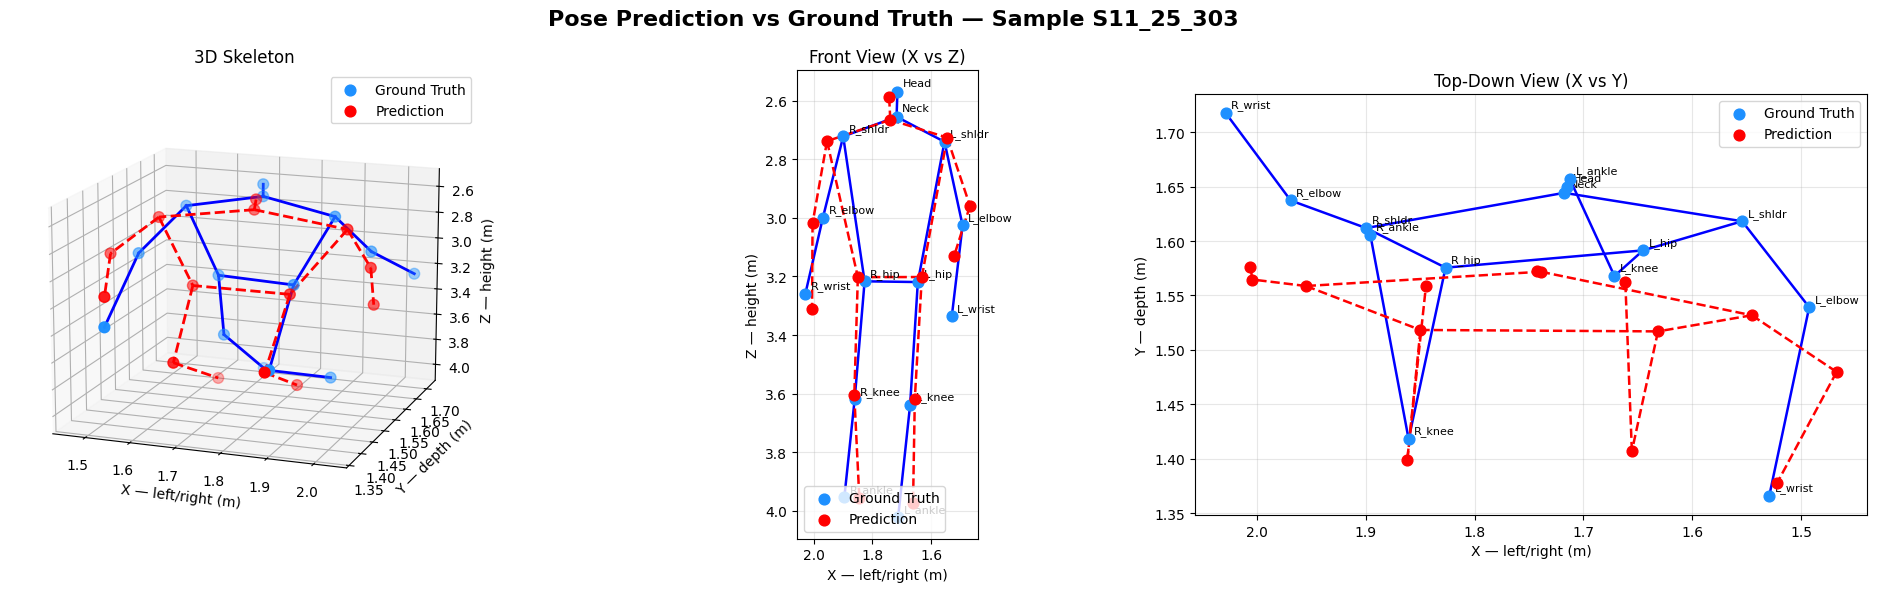

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

# --- 1. Choose a File ---
vis_dir = '/home/axnguyen/Data/WiFi-CSI/result/visualize'
all_files = os.listdir(os.path.join(vis_dir, 'pose_gt'))

# Pick a random sample or specify one explicitly
FILE_NAME = random.choice(all_files).replace('.npy', '')
# FILE_NAME = 'S11_01_308' 

print(f"Visualizing Sample: {FILE_NAME}")

# --- 2. Load Data ---
gt_path   = os.path.join(vis_dir, 'pose_gt', f'{FILE_NAME}.npy')
pred_path = os.path.join(vis_dir, 'pose_pred', f'{FILE_NAME}.npy')

# Load Skeletons (Shape: [num_people, 14, 3] -> extracting the first person)
gt_kp   = np.load(gt_path)[0]    
pred_kp = np.load(pred_path)[0]  

# --- 3. Skeleton Definitions ---
JOINT_NAMES = [
    'Neck', 'Head', 'R_shldr', 'L_shldr', 'R_elbow', 'R_hip', 
    'L_elbow', 'L_hip', 'R_wrist', 'R_knee', 'L_wrist', 'L_knee', 
    'R_ankle', 'L_ankle'
]

BONES = [
    (0, 1), (0, 2), (0, 3), (2, 4), (4, 8), (3, 6), (6, 10),
    (2, 5), (3, 7), (5, 7), (5, 9), (9, 12), (7, 11), (11, 13)
]

def draw_skeleton_2d(ax, pts_a, pts_b, names, color_pt, color_line, label):
    ax.scatter(pts_a, pts_b, c=color_pt, s=60, zorder=5, label=label)
    if label == 'Ground Truth':
        for i, (a, b) in enumerate(zip(pts_a, pts_b)):
            ax.annotate(names[i], (a, b), fontsize=8, color='black',
                        textcoords='offset points', xytext=(4, 4))
    for j1, j2 in BONES:
        ax.plot([pts_a[j1], pts_a[j2]], [pts_b[j1], pts_b[j2]],
                color=color_line, linewidth=1.8, linestyle='-' if label == 'Ground Truth' else '--')

# --- 4. Plotting ---
fig = plt.figure(figsize=(20, 6))
fig.suptitle(f'Pose Prediction vs Ground Truth — Sample {FILE_NAME}', fontsize=16, fontweight='bold')

# Plot 1: 3D Skeleton
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
# Ground Truth (Blue)
ax1.scatter(gt_kp[:, 0], gt_kp[:, 1], gt_kp[:, 2], c='dodgerblue', s=60, label='Ground Truth')
for j1, j2 in BONES:
    ax1.plot([gt_kp[j1,0], gt_kp[j2,0]], [gt_kp[j1,1], gt_kp[j2,1]], [gt_kp[j1,2], gt_kp[j2,2]], 'b-', linewidth=2)
# Prediction (Red)
ax1.scatter(pred_kp[:, 0], pred_kp[:, 1], pred_kp[:, 2], c='red', s=60, label='Prediction')
for j1, j2 in BONES:
    ax1.plot([pred_kp[j1,0], pred_kp[j2,0]], [pred_kp[j1,1], pred_kp[j2,1]], [pred_kp[j1,2], pred_kp[j2,2]], 'r--', linewidth=2)

ax1.set_title('3D Skeleton')
ax1.set_xlabel('X — left/right (m)')
ax1.set_ylabel('Y — depth (m)')
ax1.set_zlabel('Z — height (m)')
ax1.invert_zaxis()
ax1.view_init(elev=15, azim=-70)
ax1.legend()

# Plot 2: Front View
ax2 = fig.add_subplot(1, 3, 2)
draw_skeleton_2d(ax2, gt_kp[:, 0], gt_kp[:, 2], JOINT_NAMES, 'dodgerblue', 'blue', 'Ground Truth')
draw_skeleton_2d(ax2, pred_kp[:, 0], pred_kp[:, 2], JOINT_NAMES, 'red', 'red', 'Prediction')
ax2.set_title('Front View (X vs Z)')
ax2.set_xlabel('X — left/right (m)')
ax2.set_ylabel('Z — height (m)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.legend()

# Plot 3: Top-Down View
ax3 = fig.add_subplot(1, 3, 3)
draw_skeleton_2d(ax3, gt_kp[:, 0], gt_kp[:, 1], JOINT_NAMES, 'dodgerblue', 'blue', 'Ground Truth')
draw_skeleton_2d(ax3, pred_kp[:, 0], pred_kp[:, 1], JOINT_NAMES, 'red', 'red', 'Prediction')
ax3.set_title('Top-Down View (X vs Y)')
ax3.set_xlabel('X — left/right (m)')
ax3.set_ylabel('Y — depth (m)')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)
ax3.invert_xaxis()
ax3.legend()

plt.tight_layout()
plt.show()
